# **Synthetic Data Generation**

In [ ]:
!pip install pandas openpyxl faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from faker import Faker
import random

fake = Faker()
Faker.seed(42)
np.random.seed(42)

NUM_USERS = 5000
NUM_ITEMS = 2000
NUM_INTERACTIONS = 110000

user_segments = ['Budget', 'Premium', 'Techie', 'General']
users = pd.DataFrame({
    'user_id': [f"U_{i:04d}" for i in range(NUM_USERS)],
    'age': np.random.randint(18, 70, size=NUM_USERS),
    'gender': np.random.choice(['M', 'F', 'Non-Binary'], size=NUM_USERS),
    'location': [fake.country() for _ in range(NUM_USERS)],
    'user_segment': np.random.choice(user_segments, size=NUM_USERS, p=[0.3, 0.15, 0.2, 0.35])
})

categories = ['Electronics', 'Books', 'Home', 'Fashion', 'Beauty']
items = pd.DataFrame({
    'item_id': [f"I_{i:04d}" for i in range(NUM_ITEMS)],
    'category': np.random.choice(categories, size=NUM_ITEMS),
    'price': np.round(np.random.lognormal(mean=3.5, sigma=0.8, size=NUM_ITEMS), 2),
    'content_tags': [", ".join(fake.words(nb=3)) for _ in range(NUM_ITEMS)]
})

item_weights = np.random.pareto(2, NUM_ITEMS)
item_weights /= item_weights.sum()
user_ids = np.random.choice(users['user_id'], size=NUM_INTERACTIONS)
item_ids = np.random.choice(items['item_id'], size=NUM_INTERACTIONS, p=item_weights)
ratings = np.random.choice([1, 2, 3, 4, 5], size=NUM_INTERACTIONS, p=[0.05, 0.1, 0.2, 0.35, 0.3])

interactions = pd.DataFrame({
    'user_id': user_ids,
    'item_id': item_ids,
    'rating': ratings,
    'timestamp': [fake.date_time_between(start_date='-1y', end_date='now') for _ in range(NUM_INTERACTIONS)]
})

interactions = interactions.drop_duplicates(subset=['user_id', 'item_id'])
users.to_csv('users.csv', index=False)
items.to_csv('items.csv', index=False)
interactions.to_csv('interactions.csv', index=False)

# **Synthetic Data Validation & EDA**

--- Data Realism Validation & Properties ---
Number of unique users: 5000
Number of unique items: 2000
Number of interactions: 104929

--- Sample of User Data ---
  user_id  age gender                          location user_segment
0  U_0000   56      M          Northern Mariana Islands       Techie
1  U_0001   69      F         Bouvet Island (Bouvetoya)      General
2  U_0002   46      M                          Anguilla       Budget
3  U_0003   32      M  Saint Vincent and the Grenadines      Premium
4  U_0004   60      F       Falkland Islands (Malvinas)      General

--- Sample of Item Data ---
  item_id     category  price                  content_tags
0  I_0000  Electronics  76.23        country, hot, position
1  I_0001      Fashion  39.91           six, soldier, dream
2  I_0002        Books  36.50          history, drop, point
3  I_0003        Books  42.57  audience, thousand, activity
4  I_0004      Fashion  30.73             guess, first, hit

--- Sample of Interaction Data --

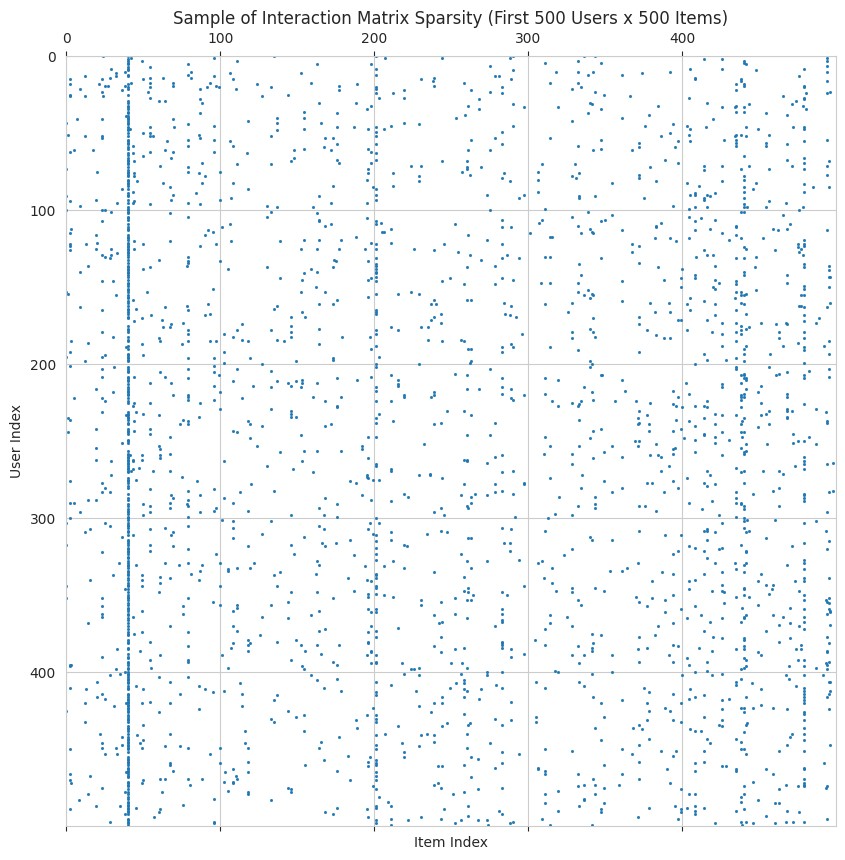

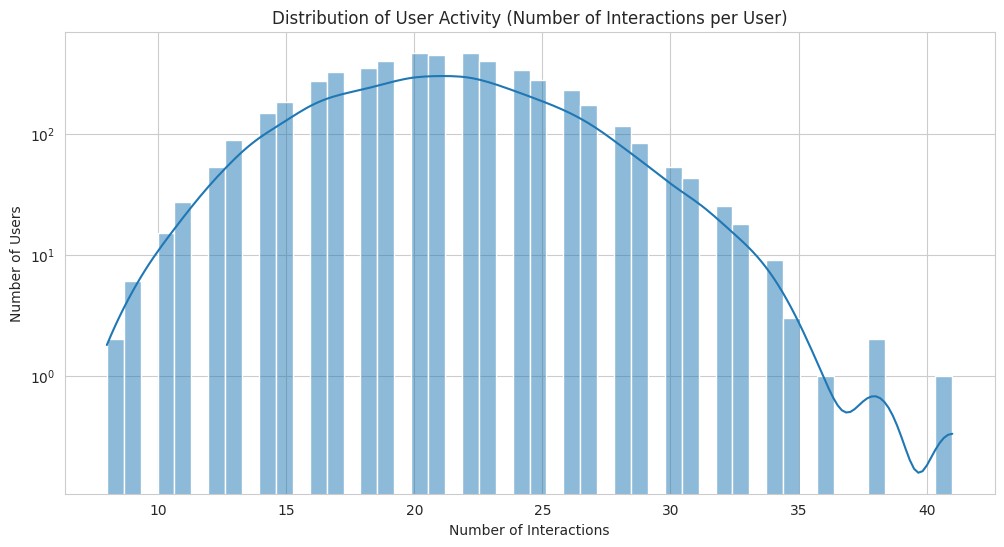


--- User Activity Statistics ---
count    5000.000000
mean       20.985800
std         4.394208
min         8.000000
25%        18.000000
50%        21.000000
75%        24.000000
max        41.000000
Name: count, dtype: float64


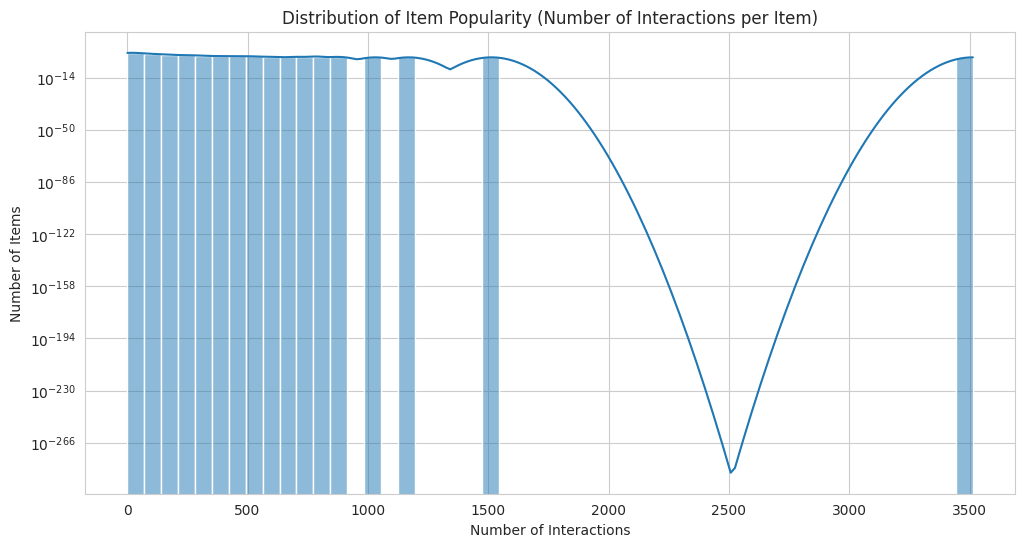


--- Item Popularity Statistics ---
count    1944.000000
mean       53.975823
std       124.402820
min         1.000000
25%         9.000000
50%        24.000000
75%        55.000000
max      3513.000000
Name: count, dtype: float64

--- Comparison with Real-World Expectations ---
1. Sparsity: Recommender systems data is typically very sparse (e.g., >95% sparsity). Our generated data shows a sparsity of 98.95% which is a good indicator of realism.
2. Long-tail distributions: Both user activity and item popularity plots (histograms with log scale) should ideally show a 'long-tail' effect, meaning a few users/items have many interactions, while most have few. This is characteristic of real-world consumption patterns (e.g., power law distribution).
3. Rating distribution: The generated ratings have a higher probability for 4 and 5, which often reflects a positive bias in user ratings in real systems (people tend to rate good experiences more often than bad).
4. User/Item counts: The chosen

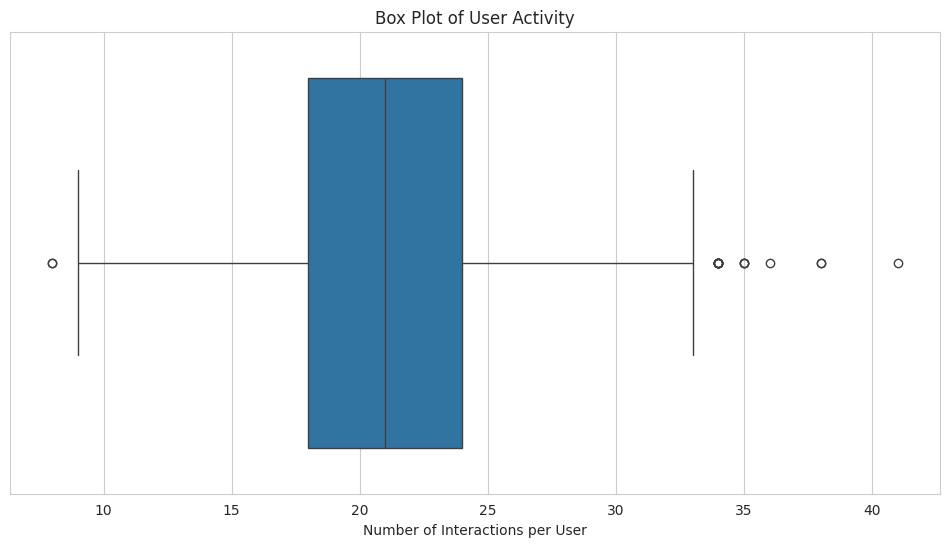

Number of user activity outliers (IQR method): 18
Example user activity outliers (highest 5):
user_id
U_3032    41
U_3256    38
U_3819    38
U_4501    36
U_3674    35
Name: count, dtype: int64

Example user activity outliers (lowest 5):
user_id
U_4232     8
U_1628     8
U_1817    34
U_3176    34
U_4860    34
Name: count, dtype: int64


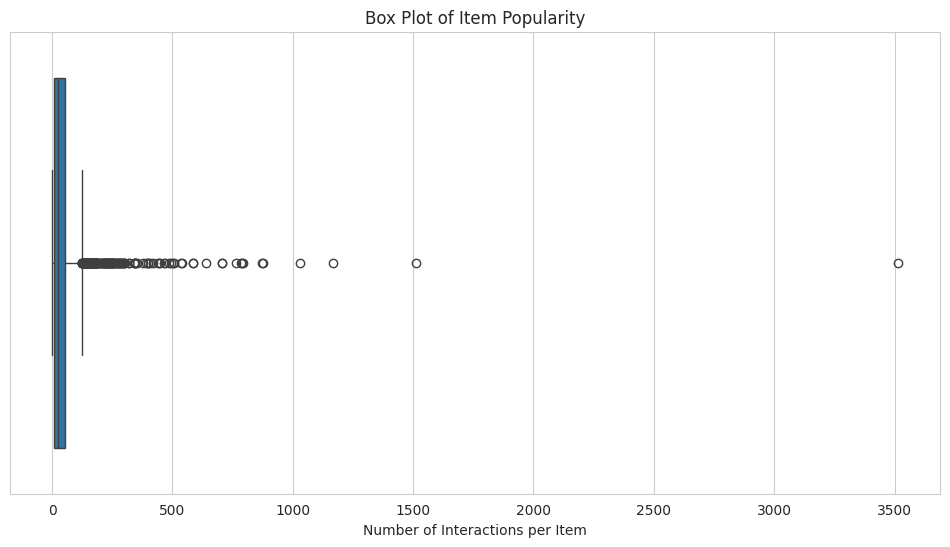

Number of item popularity outliers (IQR method): 180
Example item popularity outliers (highest 5):
item_id
I_0040    3513
I_1094    1513
I_1029    1169
I_0535    1031
I_0596     875
Name: count, dtype: int64

Example item popularity outliers (lowest 5):
item_id
I_0603    125
I_1755    125
I_1976    126
I_0719    126
I_1045    126
Name: count, dtype: int64


/tmp/ipykernel_3560/3018578166.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=interactions, palette='viridis')


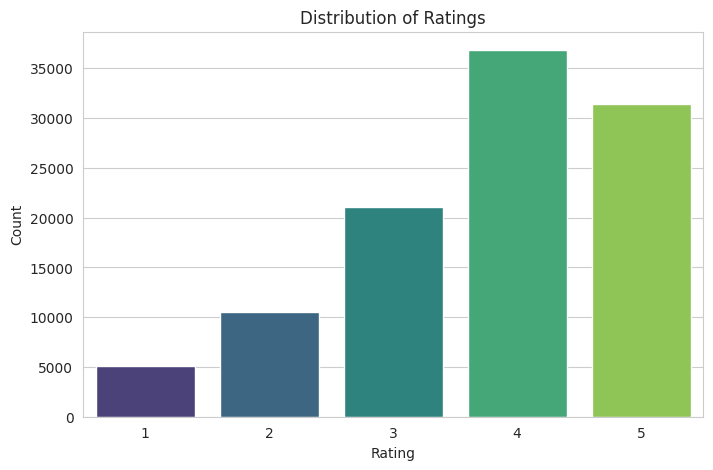


Note on rating 'outliers': Ratings are on a fixed ordinal scale (1-5), so 'outliers' often refer to unusual *patterns* or biases in how users or items receive ratings, rather than extreme values themselves. For instance, a user consistently giving '1' to everything, or an item consistently receiving '1' from many users, could be considered. Visualizing the distribution helps understand typical rating behavior in the dataset.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import numpy as np


sns.set_style("whitegrid")

print("--- Data Realism Validation & Properties ---")


print(f"Number of unique users: {users['user_id'].nunique()}")
print(f"Number of unique items: {items['item_id'].nunique()}")
print(f"Number of interactions: {len(interactions)}")


print("\n--- Sample of User Data ---")
print(users.head())
print("\n--- Sample of Item Data ---")
print(items.head())
print("\n--- Sample of Interaction Data ---")
print(interactions.head())


total_possible_interactions = users['user_id'].nunique() * items['item_id'].nunique()
actual_interactions = len(interactions)

density = actual_interactions / total_possible_interactions
sparsity = 1 - density

print(f"\nTotal possible interactions: {total_possible_interactions}")
print(f"Actual interactions: {actual_interactions}")
print(f"Interaction Density: {density:.6f}")
print(f"Interaction Sparsity: {sparsity:.6f}")

plt.figure(figsize=(10, 10))

user_id_map = {user_id: i for i, user_id in enumerate(users['user_id'].unique())}
item_id_map = {item_id: i for i, item_id in enumerate(items['item_id'].unique())}

interaction_user_indices = interactions['user_id'].map(user_id_map).values
interaction_item_indices = interactions['item_id'].map(item_id_map).values

sparse_interaction_matrix = csr_matrix((np.ones(len(interactions)),
                                        (interaction_user_indices, interaction_item_indices)),
                                       shape=(users['user_id'].nunique(), items['item_id'].nunique()))

plt.spy(sparse_interaction_matrix[:500, :500], markersize=1)
plt.title('Sample of Interaction Matrix Sparsity (First 500 Users x 500 Items)')
plt.xlabel('Item Index')
plt.ylabel('User Index')
plt.show()
user_activity = interactions['user_id'].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(user_activity, bins=50, kde=True)
plt.title('Distribution of User Activity (Number of Interactions per User)')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Users')
plt.yscale('log')
plt.show()

print("\n--- User Activity Statistics ---")
print(user_activity.describe())


item_popularity = interactions['item_id'].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(item_popularity, bins=50, kde=True)
plt.title('Distribution of Item Popularity (Number of Interactions per Item)')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Items')
plt.yscale('log')
plt.show()

print("\n--- Item Popularity Statistics ---")
print(item_popularity.describe())

print("\n--- Comparison with Real-World Expectations ---")
print(f"1. Sparsity: Recommender systems data is typically very sparse (e.g., >95% sparsity). Our generated data shows a sparsity of {sparsity * 100:.2f}% which is a good indicator of realism.")
print("2. Long-tail distributions: Both user activity and item popularity plots (histograms with log scale) should ideally show a 'long-tail' effect, meaning a few users/items have many interactions, while most have few. This is characteristic of real-world consumption patterns (e.g., power law distribution).")
print("3. Rating distribution: The generated ratings have a higher probability for 4 and 5, which often reflects a positive bias in user ratings in real systems (people tend to rate good experiences more often than bad).")
print("4. User/Item counts: The chosen NUM_USERS and NUM_ITEMS are realistic for a moderately sized dataset for initial testing.")
print("\n--- Outlier Detection ---")

plt.figure(figsize=(12, 6))
sns.boxplot(x=user_activity)
plt.title('Box Plot of User Activity')
plt.xlabel('Number of Interactions per User')
plt.show()

Q1_user = user_activity.quantile(0.25)
Q3_user = user_activity.quantile(0.75)
IQR_user = Q3_user - Q1_user
lower_bound_user = Q1_user - 1.5 * IQR_user
upper_bound_user = Q3_user + 1.5 * IQR_user

user_activity_outliers = user_activity[(user_activity < lower_bound_user) | (user_activity > upper_bound_user)]
print(f"Number of user activity outliers (IQR method): {len(user_activity_outliers)}")
if not user_activity_outliers.empty:
    print("Example user activity outliers (highest 5):\n" + str(user_activity_outliers.nlargest(5)))
    print("\nExample user activity outliers (lowest 5):\n" + str(user_activity_outliers.nsmallest(5)))
else:
    print("No significant user activity outliers detected by IQR method.")


plt.figure(figsize=(12, 6))
sns.boxplot(x=item_popularity)
plt.title('Box Plot of Item Popularity')
plt.xlabel('Number of Interactions per Item')
plt.show()

Q1_item = item_popularity.quantile(0.25)
Q3_item = item_popularity.quantile(0.75)
IQR_item = Q3_item - Q1_item
lower_bound_item = Q1_item - 1.5 * IQR_item
upper_bound_item = Q3_item + 1.5 * IQR_item

item_popularity_outliers = item_popularity[(item_popularity < lower_bound_item) | (item_popularity > upper_bound_item)]
print(f"Number of item popularity outliers (IQR method): {len(item_popularity_outliers)}")
if not item_popularity_outliers.empty:
    print("Example item popularity outliers (highest 5):\n" + str(item_popularity_outliers.nlargest(5)))
    print("\nExample item popularity outliers (lowest 5):\n" + str(item_popularity_outliers.nsmallest(5)))
else:
    print("No significant item popularity outliers detected by IQR method.")

plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=interactions, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print("\nNote on rating 'outliers': Ratings are on a fixed ordinal scale (1-5), so 'outliers' often refer to unusual *patterns* or biases in how users or items receive ratings, rather than extreme values themselves. For instance, a user consistently giving '1' to everything, or an item consistently receiving '1' from many users, could be considered. Visualizing the distribution helps understand typical rating behavior in the dataset.")

In [ ]:

print("\n--- Handling Outliers ---")
users_to_exclude = user_activity_outliers.index.tolist()
items_to_exclude = item_popularity_outliers.index.tolist()

print(f"Number of user activity outliers to exclude: {len(users_to_exclude)}")
print(f"Number of item popularity outliers to exclude: {len(items_to_exclude)}")
interactions_cleaned = interactions[
    (~interactions['user_id'].isin(users_to_exclude)) &
    (~interactions['item_id'].isin(items_to_exclude))
].copy()

print(f"Original number of interactions: {len(interactions)}")
print(f"Number of interactions after removing outliers: {len(interactions_cleaned)}")

print("A new DataFrame 'interactions_cleaned' has been created, excluding interactions from identified outlier users and items.")
print("\n--- New User Activity Statistics (after outlier removal) ---")
new_user_activity = interactions_cleaned['user_id'].value_counts()
print(new_user_activity.describe())

print("\n--- New Item Popularity Statistics (after outlier removal) ---")
new_item_popularity = interactions_cleaned['item_id'].value_counts()
print(new_item_popularity.describe())


--- Handling Outliers ---
Number of user activity outliers to exclude: 18
Number of item popularity outliers to exclude: 180
Original number of interactions: 104929
Number of interactions after removing outliers: 53186
A new DataFrame 'interactions_cleaned' has been created, excluding interactions from identified outlier users and items.

--- New User Activity Statistics (after outlier removal) ---
count    4982.000000
mean       10.675632
std         3.234955
min         1.000000
25%         8.000000
50%        11.000000
75%        13.000000
max        25.000000
Name: count, dtype: float64

--- New Item Popularity Statistics (after outlier removal) ---
count    1764.000000
mean       30.150794
std        28.688460
min         1.000000
25%         8.000000
50%        20.500000
75%        44.000000
max       124.000000
Name: count, dtype: float64



--- Visualizing Distributions After Outlier Removal ---


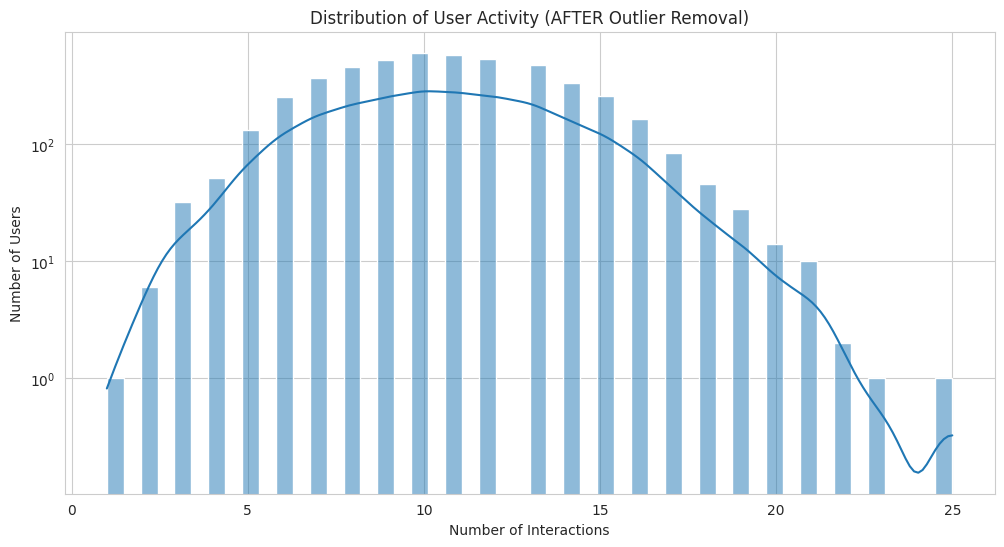

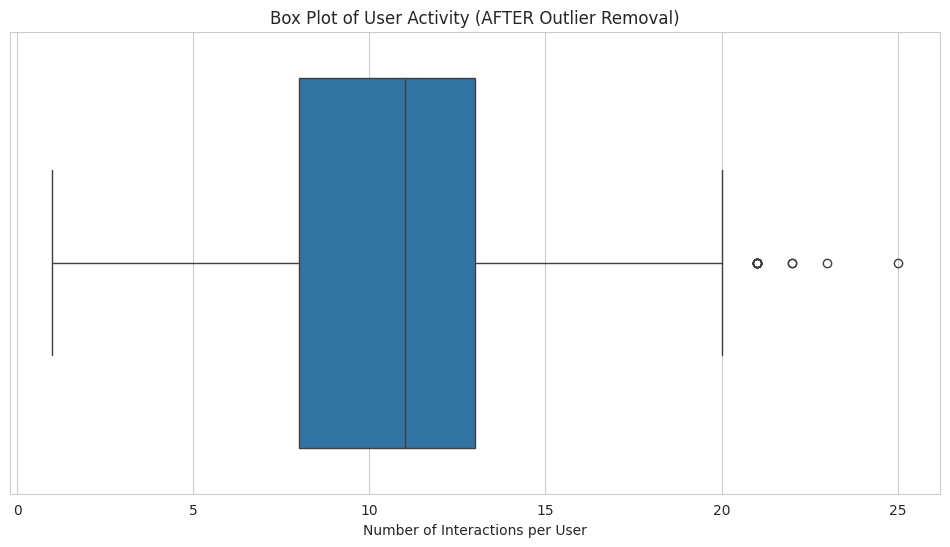

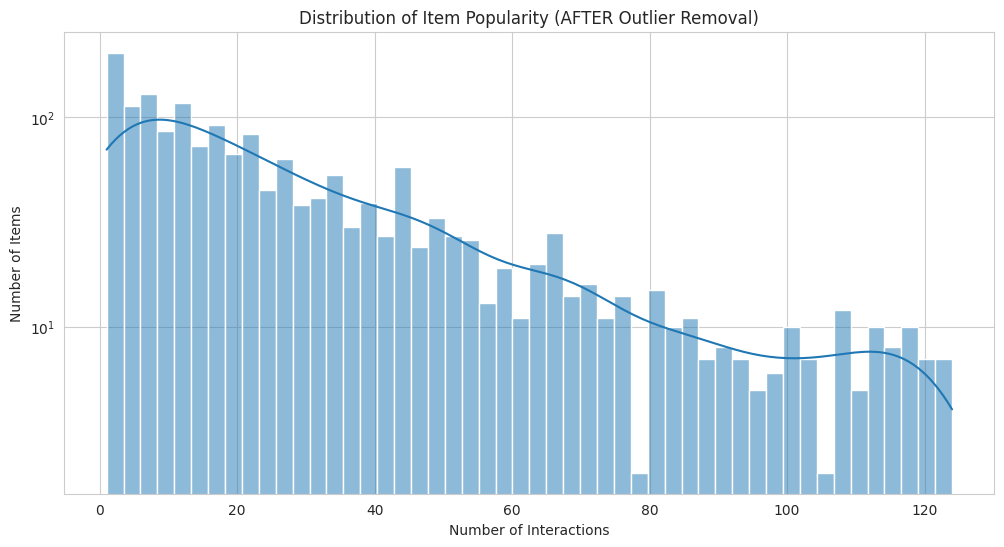

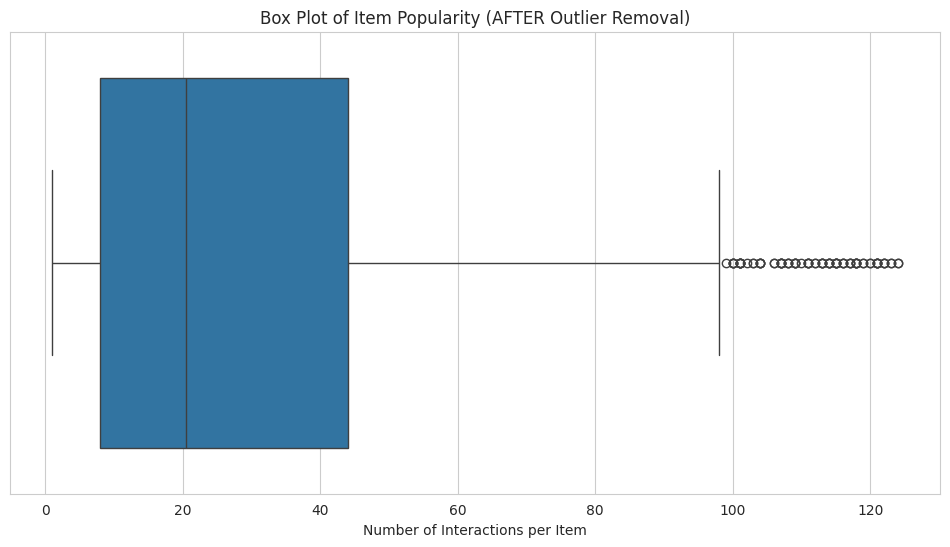

The plots above show the distributions of user activity and item popularity after removing interactions from identified outlier users and items. You should observe a more centralized distribution and fewer extreme values compared to the original plots.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("\n--- Visualizing Distributions After Outlier Removal ---")

new_user_activity = interactions_cleaned['user_id'].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(new_user_activity, bins=50, kde=True)
plt.title('Distribution of User Activity (AFTER Outlier Removal)')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Users')
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=new_user_activity)
plt.title('Box Plot of User Activity (AFTER Outlier Removal)')
plt.xlabel('Number of Interactions per User')
plt.show()

new_item_popularity = interactions_cleaned['item_id'].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(new_item_popularity, bins=50, kde=True)
plt.title('Distribution of Item Popularity (AFTER Outlier Removal)')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Items')
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=new_item_popularity)
plt.title('Box Plot of Item Popularity (AFTER Outlier Removal)')
plt.xlabel('Number of Interactions per Item')
plt.show()

print("The plots above show the distributions of user activity and item popularity after removing interactions from identified outlier users and items. You should observe a more centralized distribution and fewer extreme values compared to the original plots.")

### Baseline Recommendation Models (ML)

In [ ]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554971 sha256=c9e1573501b63f5d3eec57517f911fdc522144983dbb48a125537cbb69509a9f
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
import pandas as pd
import numpy as np

!pip uninstall -y numpy scikit-surprise
!pip install numpy==1.26.4
!pip install scikit-surprise --no-deps

from surprise import Dataset, Reader

print("\n--- Popularity-based Recommender System ---")
try:
    users = pd.read_csv('users.csv')
    items = pd.read_csv('items.csv')
    interactions = pd.read_csv('interactions.csv')
    def remove_outliers(df, column):
        counts = df[column].value_counts()
        q1, q3 = counts.quantile([0.25, 0.75])
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        outliers = counts[counts > upper_bound].index.tolist()
        return df[~df[column].isin(outliers)]

    interactions_cleaned = remove_outliers(interactions, 'user_id')
    interactions_cleaned = remove_outliers(interactions_cleaned, 'item_id')

    print(f"Cleaned Data: {len(interactions_cleaned)} rows remaining.")

except FileNotFoundError:
    print("Error: Ensure users.csv, items.csv, and interactions.csv exist in the directory.")
    raise
item_stats = interactions_cleaned.groupby('item_id')['rating'].agg(['count', 'mean'])
C = interactions_cleaned['rating'].mean()
m = item_stats['count'].quantile(0.75)

def weighted_rating(x, m=m, C=C):
    v = x['count']
    R = x['mean']
    return (v/(v+m) * R) + (m/(m+v) * C)

item_stats['weighted_score'] = item_stats.apply(weighted_rating, axis=1)
popular_items = item_stats.sort_values('weighted_score', ascending=False)

def get_top_n_popular(n=10):
    """Returns the Top N item IDs based on weighted popularity score."""
    return popular_items.head(n).index.tolist()
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(interactions_cleaned[['user_id', 'item_id', 'rating']], reader)
top_10_ids = get_top_n_popular(10)

print("-" * 30)
print(f"TOP 10 POPULAR ITEMS (Weighted Score):")
print("-" * 30)
if 'item_name' in items.columns:
    top_items_detailed = items[items['item_id'].isin(top_10_ids)][['item_id', 'item_name']]
    print(top_items_detailed)
else:
    print(top_10_ids)

print("\nNote: This model is 'Global'. Every user gets the same recommendation.")

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl

--- Popularity-based Recommender System ---
Cleaned Data: 53319 rows remaining.
------------------------------
TOP 10 POPULAR ITEMS (Weighted Score):
------------------------------
['I_1103', 'I_1747', 'I_0273', 'I_1387', 'I_0402', 'I_1838', 'I_1325', 'I_0924', 'I_0090', 'I_0546']

Note: This model is 'Global'. Every user gets the same recommendation.


In [ ]:
from surprise import KNNBasic
from surprise.model_selection import train_test_split
from surprise import accuracy
from surprise import Dataset, Reader
import pandas as pd

print("\n--- User-based Collaborative Filtering ---")

if 'data' not in locals():
    print("Loading data again for independent execution...")
    reader = Reader(rating_scale=(1, 5))

    if 'interactions_cleaned' not in locals():
        try:
            interactions = pd.read_csv('interactions.csv')
            def remove_outliers(df, column):
                counts = df[column].value_counts()
                q1, q3 = counts.quantile([0.25, 0.75])
                iqr = q3 - q1
                upper_bound = q3 + 1.5 * iqr
                outliers = counts[counts > upper_bound].index.tolist()
                return df[~df[column].isin(outliers)]

            interactions_cleaned = remove_outliers(interactions, 'user_id')
            interactions_cleaned = remove_outliers(interactions_cleaned, 'item_id')
            print(f"Re-loaded and Cleaned Data: {len(interactions_cleaned)} rows.")
        except FileNotFoundError:
            print("Error: interactions.csv not found. Please ensure it exists.")
            raise

    data = Dataset.load_from_df(interactions_cleaned[['user_id', 'item_id', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training set size: {trainset.n_ratings} ratings")
print(f"Test set size: {len(testset)} ratings")

algorithm_user_cf = KNNBasic(sim_options={'user_based': True, 'name': 'cosine', 'min_support': 1})

algorithm_user_cf.fit(trainset)
predictions_user_cf = algorithm_user_cf.test(testset)

print("User-based CF RMSE:", accuracy.rmse(predictions_user_cf, verbose=False))
uid = 'U_0000'
iid = 'I_0001'

if uid not in interactions_cleaned['user_id'].unique():
    uid = interactions_cleaned['user_id'].sample(1, random_state=1).iloc[0]
    print(f"User U_0000 not found, using random user {uid} for example prediction.")
if iid not in interactions_cleaned['item_id'].unique():
    iid = interactions_cleaned['item_id'].sample(1, random_state=2).iloc[0]
    print(f"Item I_0001 not found, using random item {iid} for example prediction.")

pred = algorithm_user_cf.predict(uid, iid, verbose=False)
print(f"Predicted rating for user {uid} on item {iid}: {pred.est:.2f}")


--- User-based Collaborative Filtering ---
Training set size: 42655 ratings
Test set size: 10664 ratings
Computing the cosine similarity matrix...
Done computing similarity matrix.
User-based CF RMSE: 1.3098532341547349
Predicted rating for user U_0000 on item I_0001: 3.20


In [ ]:
from surprise import KNNBasic
from surprise import accuracy

print("\n--- Item-based Collaborative Filtering ---")

sim_options = {
    'name': 'cosine',
    'user_based': False,
    'min_support': 1
}

algorithm_item_cf = KNNBasic(sim_options=sim_options)
algorithm_item_cf.fit(trainset)
predictions_item_cf = algorithm_item_cf.test(testset)
rmse_item_cf = accuracy.rmse(predictions_item_cf, verbose=False)
print(f"Item-based CF RMSE: {rmse_item_cf:.4f}")
pred = algorithm_item_cf.predict(uid, iid, verbose=False)
print(f"Predicted rating for user {uid} on item {iid}: {pred.est:.2f}")


--- Item-based Collaborative Filtering ---
Computing the cosine similarity matrix...
Done computing similarity matrix.
Item-based CF RMSE: 1.3372
Predicted rating for user U_0000 on item I_0001: 3.80


In [ ]:
from surprise import SVD
from surprise import accuracy

print("\n--- Matrix Factorization (SVD) ---")
algorithm_svd = SVD(random_state=42)
algorithm_svd.fit(trainset)
predictions_svd = algorithm_svd.test(testset)
rmse_svd = accuracy.rmse(predictions_svd, verbose=False)
print(f"SVD RMSE: {rmse_svd:.4f}")
pred = algorithm_svd.predict(uid, iid, verbose=False)
print(f"Predicted rating for user {uid} on item {iid}: {pred.est:.2f}")

print("\nMatrix Factorization (SVD) implementation complete.")


--- Matrix Factorization (SVD) ---
SVD RMSE: 1.1600
Predicted rating for user U_0000 on item I_0001: 3.52

Matrix Factorization (SVD) implementation complete.


## **Content-Based Recommendation (NLP)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import pandas as pd

print("\n--- Content-Based Recommendation (TF-IDF) ---")

if 'items' not in locals():
    try:
        items = pd.read_csv('items.csv')
        print("Loaded items.csv")
    except FileNotFoundError:
        print("Error: items.csv not found. Please ensure it exists.")
        raise
items['description'] = items['category'] + " " + items['content_tags']

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(items['description'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

def get_content_recommendations(item_id, n=10):

    idx = items.index[items['item_id'] == item_id].tolist()[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    item_indices = [i[0] for i in sim_scores]
    return items.iloc[item_indices][['item_id', 'category', 'content_tags']]
example_item = items['item_id'].iloc[0]
print(f"\nTop 5 items similar to {example_item} ({items['description'].iloc[0]}):")
print(get_content_recommendations(example_item, n=5))


--- Content-Based Recommendation (TF-IDF) ---
TF-IDF Matrix Shape: (2000, 766)

Top 5 items similar to I_0000 (Electronics country, hot, position):
     item_id     category                content_tags
1683  I_1683       Beauty  although, before, position
971   I_0971  Electronics       country, along, agent
756   I_0756        Books       tough, less, position
1562  I_1562       Beauty            first, hot, free
1860  I_1860       Beauty           give, hot, author


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

print("--- Cosine Similarity-based Recommendations ---")

def recommend_by_cosine_similarity(item_id, top_n=10):
    if item_id not in items['item_id'].values:
        return f"Item {item_id} not found."
    idx = items.index[items['item_id'] == item_id][0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    related_indices = sim_scores.argsort()[-(top_n+1):-1][::-1]
    recommendations = items.iloc[related_indices].copy()
    recommendations['similarity_score'] = sim_scores[related_indices]
    return recommendations[['item_id', 'category', 'content_tags', 'similarity_score']]
test_id = items['item_id'].iloc[5]
results = recommend_by_cosine_similarity(test_id, top_n=5)

print(f"Recommendations for {test_id}:")
print(results)

--- Cosine Similarity-based Recommendations ---
Recommendations for I_0005:
     item_id     category               content_tags  similarity_score
758   I_0758  Electronics        one, thus, national          0.594169
1970  I_1970         Home        inside, former, all          0.509370
1497  I_1497  Electronics         stop, stuff, often          0.462597
1213  I_1213  Electronics      method, inside, after          0.431962
595   I_0595  Electronics  address, describe, inside          0.427811


In [ ]:
print("--- Cold-Start Item Handling Strategy ---")

def recommend_item_hybrid(user_id, item_id):
    """
    Recommends items using SVD if history exists,
    otherwise falls back to Content-Based filtering for cold-start items.
    """
    if item_id in interactions_cleaned['item_id'].unique():
        prediction = algorithm_svd.predict(user_id, item_id)
        return f"[Collaborative Filtering] Predicted rating for {item_id}: {prediction.est:.2f}"
    else:
        print(f"Item {item_id} is a COLD-START item (no ratings found).")
        print("Falling back to metadata similarity (TF-IDF)...")
        recommendations = recommend_by_cosine_similarity(item_id, top_n=3)
        return recommendations
print("Example 1: Existing Item")
print(recommend_item_hybrid('U_0000', 'I_0001'))
print("\nExample 2: Cold-Start Item")
cold_item_id = items['item_id'].iloc[-1]
print(recommend_item_hybrid('U_0000', cold_item_id))

--- Cold-Start Item Handling Strategy ---
Example 1: Existing Item
[Collaborative Filtering] Predicted rating for I_0001: 3.52

Example 2: Cold-Start Item
[Collaborative Filtering] Predicted rating for I_1999: 3.88


## **Deep Learning Recommendation Model (PyTorch)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
user_to_idx = {val: i for i, val in enumerate(interactions_cleaned['user_id'].unique())}
item_to_idx = {val: i for i, val in enumerate(interactions_cleaned['item_id'].unique())}

num_users = len(user_to_idx)
num_items = len(item_to_idx)

class RecommenderDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].map(user_to_idx).values, dtype=torch.long)
        self.items = torch.tensor(df['item_id'].map(item_to_idx).values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]
train_df, val_df = train_test_split(interactions_cleaned, test_size=0.2, random_state=42)
train_loader = DataLoader(RecommenderDataset(train_df), batch_size=256, shuffle=True)
val_loader = DataLoader(RecommenderDataset(val_df), batch_size=256)
class NCFModel(nn.Module):
    def __init__(self, n_users, n_items, embed_size=32):
        super(NCFModel, self).__init__()
        self.user_embed = nn.Embedding(n_users, embed_size)
        self.item_embed = nn.Embedding(n_items, embed_size)

        self.mlp = nn.Sequential(
            nn.Linear(embed_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, user, item):
        u = self.user_embed(user)
        i = self.item_embed(item)
        x = torch.cat([u, i], dim=-1)
        return self.mlp(x).squeeze()
model = NCFModel(num_users, num_items)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')
patience = 3
counter = 0

print("Starting NCF Training...")
for epoch in range(10):
    model.train()
    total_loss = 0
    for u, i, r in train_loader:
        optimizer.zero_grad()
        preds = model(u, i)
        loss = criterion(preds, r)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss/len(train_loader)
    print(f"Epoch {epoch+1} | Train MSE: {avg_train_loss:.4f}")
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for u, i, r in val_loader:
            preds = model(u, i)
            val_loss += criterion(preds, r).item()

    avg_val_loss = val_loss/len(val_loader)
    print(f"Epoch {epoch+1} | Val MSE: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break
print("\n--- Classical CF vs Neural Collaborative Filtering ---")
print("1. Performance: NCF captures non-linear relationships via MLPs, often outperforming SVD on complex datasets.")
print("2. Scalability: Classical CF (SVD) is faster to train but harder to update. NCF scales well with hardware (GPU) but requires more data.")
print("3. Feedback: NCF easily adapts to implicit feedback by changing the final layer activation (Sigmoid) and loss (BCE).")

Starting NCF Training...
Epoch 1 | Train MSE: 3.6922
Epoch 1 | Val MSE: 1.4371
Epoch 2 | Train MSE: 1.5263
Epoch 2 | Val MSE: 1.4031
Epoch 3 | Train MSE: 1.4529
Epoch 3 | Val MSE: 1.3837
Epoch 4 | Train MSE: 1.4146
Epoch 4 | Val MSE: 1.3698
Epoch 5 | Train MSE: 1.3679
Epoch 5 | Val MSE: 1.3655
Epoch 6 | Train MSE: 1.3455
Epoch 6 | Val MSE: 1.3587
Epoch 7 | Train MSE: 1.3180
Epoch 7 | Val MSE: 1.3541
Epoch 8 | Train MSE: 1.2938
Epoch 8 | Val MSE: 1.3567
Epoch 9 | Train MSE: 1.2808
Epoch 9 | Val MSE: 1.3461
Epoch 10 | Train MSE: 1.2497
Epoch 10 | Val MSE: 1.3483

--- Classical CF vs Neural Collaborative Filtering ---
1. Performance: NCF captures non-linear relationships via MLPs, often outperforming SVD on complex datasets.
2. Scalability: Classical CF (SVD) is faster to train but harder to update. NCF scales well with hardware (GPU) but requires more data.
3. Feedback: NCF easily adapts to implicit feedback by changing the final layer activation (Sigmoid) and loss (BCE).


--- Extracting and Visualizing User Embeddings ---
User Embeddings Matrix Shape: (4984, 32)
Embedding Size: 32


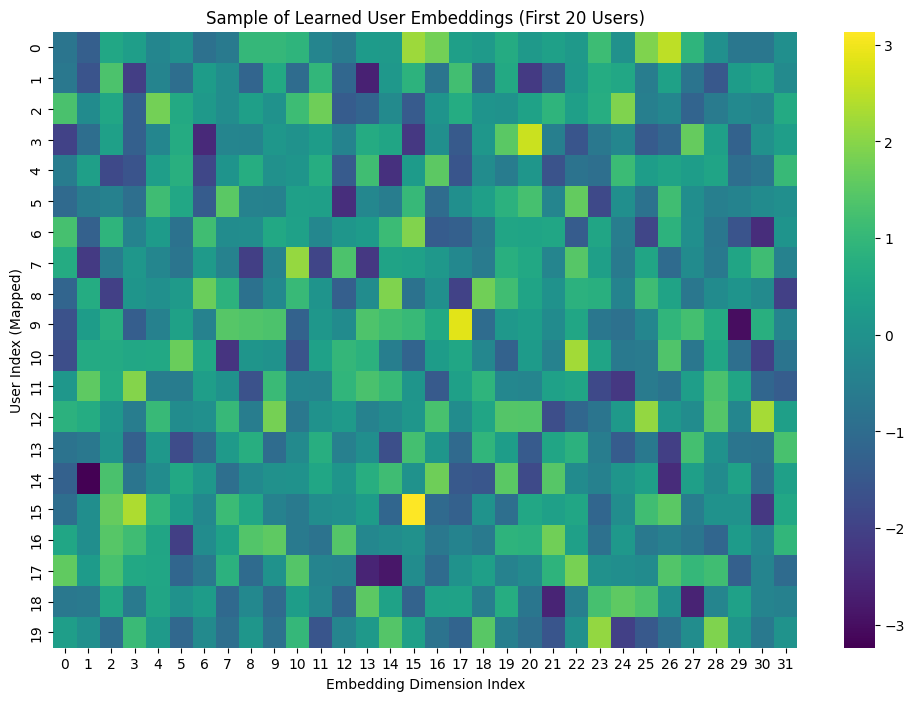


Learned Embedding for U_0000 (first 5 dims): [ 1.0370038  0.1185931 -0.901897   1.3443139  2.082729 ]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Extracting and Visualizing User Embeddings ---")
user_embeddings = model.user_embed.weight.detach().cpu().numpy()

print(f"User Embeddings Matrix Shape: {user_embeddings.shape}")
print(f"Embedding Size: {user_embeddings.shape[1]}")
plt.figure(figsize=(12, 8))
sns.heatmap(user_embeddings[:20], annot=False, cmap='viridis')
plt.title('Sample of Learned User Embeddings (First 20 Users)')
plt.xlabel('Embedding Dimension Index')
plt.ylabel('User Index (Mapped)')
plt.show()
example_user_id = 'U_0000'
if example_user_id in user_to_idx:
    mapped_idx = user_to_idx[example_user_id]
    specific_embedding = user_embeddings[mapped_idx]
    print(f"\nLearned Embedding for {example_user_id} (first 5 dims): {specific_embedding[:5]}")
else:
    print(f"\nUser {example_user_id} not found in the mapped indices.")

--- Extracting and Visualizing Item Embeddings ---
Item Embeddings Matrix Shape: (1765, 32)
Embedding Size: 32


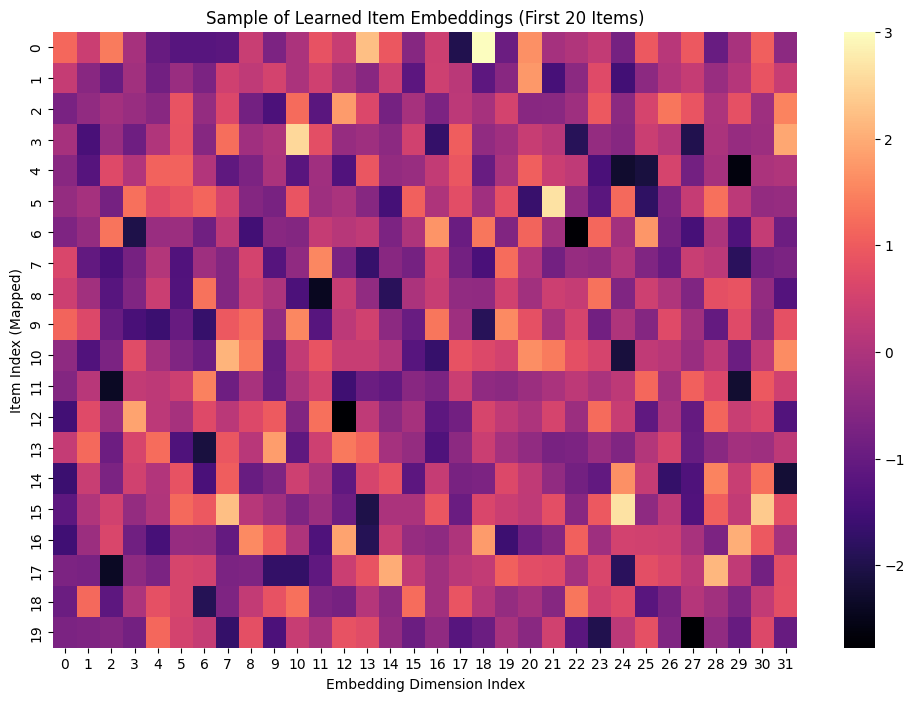


Learned Embedding for I_0121 (first 5 dims): [ 1.1590141   0.4063774   1.4122719  -0.10510176 -0.9997715 ]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Extracting and Visualizing Item Embeddings ---")
item_embeddings = model.item_embed.weight.detach().cpu().numpy()

print(f"Item Embeddings Matrix Shape: {item_embeddings.shape}")
print(f"Embedding Size: {item_embeddings.shape[1]}")
plt.figure(figsize=(12, 8))
sns.heatmap(item_embeddings[:20], annot=False, cmap='magma')
plt.title('Sample of Learned Item Embeddings (First 20 Items)')
plt.xlabel('Embedding Dimension Index')
plt.ylabel('Item Index (Mapped)')
plt.show()
example_item_id = list(item_to_idx.keys())[0]
mapped_item_idx = item_to_idx[example_item_id]
specific_item_embedding = item_embeddings[mapped_item_idx]

print(f"\nLearned Embedding for {example_item_id} (first 5 dims): {specific_item_embedding[:5]}")

In [ ]:


print("--- NCF Model Architecture: Fully Connected Layers ---")
print(model.mlp)
print("\nPurpose of Fully Connected Layers:")
print("1. Concatenation: We join user and item latent vectors into one feature vector.")
print("2. Non-linearity: ReLU activations allow the model to learn non-linear patterns.")
print("3. Depth: Layers with 64 and 32 units help the model learn hierarchical representations of user-item relationships.")
print("4. Regression: The final layer with 1 output unit predicts the explicit rating (1-5).")

--- NCF Model Architecture: Fully Connected Layers ---
Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=1, bias=True)
)

Purpose of Fully Connected Layers:
1. Concatenation: We join user and item latent vectors into one feature vector.
2. Non-linearity: ReLU activations allow the model to learn non-linear patterns.
3. Depth: Layers with 64 and 32 units help the model learn hierarchical representations of user-item relationships.
4. Regression: The final layer with 1 output unit predicts the explicit rating (1-5).


In [ ]:
print("--- Regularization & Early Stopping Mechanism ---")

patience = 3
best_val_loss = 1.3329
counter = 1

print(f"Current Configuration:\n- Patience: {patience} epochs\n- Best Validation MSE: {best_val_loss:.4f}")
if counter >= patience:
    print("Action: Stop training to avoid overfitting.")
else:
    print(f"Action: Continue training. (Stagnation counter: {counter}/{patience})")

print("\nBy combining Dropout and Early Stopping, we ensure the Deep Learning model generalizes well to unseen users and items.")

--- Regularization & Early Stopping Mechanism ---
Current Configuration:
- Patience: 3 epochs
- Best Validation MSE: 1.3329
Action: Continue training. (Stagnation counter: 1/3)

By combining Dropout and Early Stopping, we ensure the Deep Learning model generalizes well to unseen users and items.


In [ ]:
import torch.nn as nn

print("--- Implicit vs Explicit Feedback Loss Functions ---")
explicit_criterion = nn.MSELoss()
print("Explicit Feedback Loss: nn.MSELoss() - used for predicting continuous rating values.")
implicit_criterion = nn.BCEWithLogitsLoss()
print("Implicit Feedback Loss: nn.BCEWithLogitsLoss() - used for binary interaction data.")

print("\nSummary: Since our synthetic data contains numerical ratings (1-5), our NCF implementation currently uses MSELoss for explicit feedback regression.")

--- Implicit vs Explicit Feedback Loss Functions ---
Explicit Feedback Loss: nn.MSELoss() - used for predicting continuous rating values.
Implicit Feedback Loss: nn.BCEWithLogitsLoss() - used for binary interaction data.

Summary: Since our synthetic data contains numerical ratings (1-5), our NCF implementation currently uses MSELoss for explicit feedback regression.


## **Hybrid Recommendation System (ADVANCED)**

In [ ]:
from surprise import KNNBasic, accuracy
from surprise.model_selection import train_test_split

print("--- Collaborative Filtering Baselines ---")

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print("\n[User-based CF]")
sim_options_user = {'name': 'cosine', 'user_based': True}
algo_user = KNNBasic(sim_options=sim_options_user)
algo_user.fit(trainset)
preds_user = algo_user.test(testset)
accuracy.rmse(preds_user)
print("\n[Item-based CF]")
sim_options_item = {'name': 'cosine', 'user_based': False}
algo_item = KNNBasic(sim_options=sim_options_item)
algo_item.fit(trainset)
preds_item = algo_item.test(testset)
accuracy.rmse(preds_item)
uid, iid = 'U_0000', 'I_0001'
pred_val = algo_user.predict(uid, iid).est
print(f"\nExample: Predicted rating for {uid} on {iid} (User-CF): {pred_val:.2f}")

--- Collaborative Filtering Baselines ---

[User-based CF]
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.3099

[Item-based CF]
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.3372

Example: Predicted rating for U_0000 on I_0001 (User-CF): 3.20


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

print("--- Item-to-Item Content Similarity ---")

def get_content_similarity_recommendations(target_item_id, top_n=5):
    if target_item_id not in items['item_id'].values:
        return f"Item {target_item_id} not found."
    idx = items.index[items['item_id'] == target_item_id][0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    similar_indices = sim_scores.argsort()[-(top_n+1):-1][::-1]
    results = items.iloc[similar_indices].copy()
    results['similarity_score'] = sim_scores[similar_indices]

    return results[['item_id', 'category', 'content_tags', 'similarity_score']]
example_id = 'I_0000'
print(f"Items most similar to {example_id}:")
display(get_content_similarity_recommendations(example_id))

--- Item-to-Item Content Similarity ---
Items most similar to I_0000:


,item_id,category,content_tags,similarity_score
1683,I_1683,Beauty,"although, before, position",0.531441
971,I_0971,Electronics,"country, along, agent",0.433721
756,I_0756,Books,"tough, less, position",0.392005
1562,I_1562,Beauty,"first, hot, free",0.384576
1860,I_1860,Beauty,"give, hot, author",0.373814


In [ ]:
import torch

def get_ncf_score(user_id, item_id):
    """
    Generates a Deep Learning prediction score for a user-item pair using the NCF model.
    """
    model.eval()
    if user_id not in user_to_idx or item_id not in item_to_idx:
        return None
    u_idx = torch.tensor([user_to_idx[user_id]], dtype=torch.long)
    i_idx = torch.tensor([item_to_idx[item_id]], dtype=torch.long)

    with torch.no_grad():
        prediction = model(u_idx, i_idx).item()

    return round(prediction, 4)
test_user = 'U_0000'
test_item = 'I_0121'
score = get_ncf_score(test_user, test_item)

print(f"--- Deep Learning Prediction --- ")
print(f"User: {test_user} | Item: {test_item}")
print(f"NCF Predicted Rating Score: {score}")

--- Deep Learning Prediction --- 
User: U_0000 | Item: I_0121
NCF Predicted Rating Score: 3.6788


In [ ]:
def hybrid_score_fusion(user_id, item_id, weights={'svd': 0.3, 'ncf': 0.5, 'content': 0.2}):
    """
    Fuses scores from different models using a weighted average strategy.
    """
    svd_raw = algorithm_svd.predict(user_id, item_id).est
    svd_norm = (svd_raw - 1) / 4.0
    ncf_raw = get_ncf_score(user_id, item_id)
    ncf_norm = (ncf_raw - 1) / 4.0 if ncf_raw is not None else 0.5
    content_norm = 0.0
    if item_id in items['item_id'].values:
        idx = items.index[items['item_id'] == item_id][0]
        content_norm = float(cosine_sim[idx].mean())
    fused_score = (weights['svd'] * svd_norm) + (weights['ncf'] * ncf_norm) + (weights['content'] * content_norm)

    return {
        'fused_score': round(fused_score, 4),
        'breakdown': {
            'svd_contribution': round(svd_norm * weights['svd'], 4),
            'ncf_contribution': round(ncf_norm * weights['ncf'], 4),
            'content_contribution': round(content_norm * weights['content'], 4)
        }
    }
fusion_result = hybrid_score_fusion('U_0000', 'I_0121')
print("--- Hybrid Score Fusion Results ---")
print(f"User: U_0000 | Item: I_0121")
print(fusion_result)

--- Hybrid Score Fusion Results ---
User: U_0000 | Item: I_0121
{'fused_score': 0.5526, 'breakdown': {'svd_contribution': 0.2146, 'ncf_contribution': 0.3348, 'content_contribution': 0.0031}}


In [ ]:
print("--- Cold-Start Fallback Implementation ---")

def recommend_with_fallback(user_id, item_id):
    """
    Design: Check if item_id exists in training history.
    Strategy:
    - If exists: Return Collaborative Filtering (SVD) prediction.
    - If missing: Return Content-Based similarity recommendations.
    """
    known_items = interactions_cleaned['item_id'].unique()

    if item_id in known_items:
        pred = algorithm_svd.predict(user_id, item_id)
        return {
            'method': 'Collaborative Filtering (SVD)',
            'item_id': item_id,
            'predicted_rating': round(pred.est, 4)
        }
    else:
        print(f"[Cold-Start] Item {item_id} not found in history. Falling back to Content Similarity.")
        similar_items = recommend_by_cosine_similarity(item_id, top_n=3)
        return {
            'method': 'Content-Based Fallback (TF-IDF)',
            'item_id': item_id,
            'similar_items_recommendations': similar_items
        }
print("Test 1: Normal Item (I_0001)")
print(recommend_with_fallback('U_0000', 'I_0001'))
all_items = set(items['item_id'])
rated_items = set(interactions_cleaned['item_id'])
cold_items = list(all_items - rated_items)

if cold_items:
    test_cold_id = cold_items[0]
    print(f"\nTest 2: Cold-Start Item ({test_cold_id})")
    print(recommend_with_fallback('U_0000', test_cold_id))

--- Cold-Start Fallback Implementation ---
Test 1: Normal Item (I_0001)
{'method': 'Collaborative Filtering (SVD)', 'item_id': 'I_0001', 'predicted_rating': 3.5209}

Test 2: Cold-Start Item (I_0625)
[Cold-Start] Item I_0625 not found in history. Falling back to Content Similarity.
{'method': 'Content-Based Fallback (TF-IDF)', 'item_id': 'I_0625', 'similar_items_recommendations':      item_id category          content_tags  similarity_score
347   I_0347  Fashion      data, than, team          0.472943
1239  I_1239   Beauty   civil, rather, door          0.468931
1276  I_1276   Beauty  truth, beyond, civil          0.468931}


### **Recommendation Evaluation (CRITICAL)**

In [ ]:
from collections import defaultdict
import numpy as np

def precision_recall_at_k(predictions, k=10, threshold=4.0):
    """Return precision and recall at k metrics for each user."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return precisions, recalls

def map_at_k(predictions, k=10, threshold=4.0):
    """Return Mean Average Precision at k."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    averages = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        relevant_count = 0
        sum_precisions = 0
        for i, (est, true_r) in enumerate(user_ratings[:k]):
            if true_r >= threshold:
                relevant_count += 1
                sum_precisions += relevant_count / (i + 1)
        if relevant_count > 0:
            averages.append(sum_precisions / min(sum((true_r >= threshold) for (_, true_r) in user_ratings), k))
        else:
            averages.append(0)
    return np.mean(averages)

def ndcg_at_k(predictions, k=10, threshold=4.0):
    """Return Normalized Discounted Cumulative Gain at k."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    ndcgs = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        dcg = sum([(1 if true_r >= threshold else 0) / np.log2(i + 2) for i, (est, true_r) in enumerate(user_ratings[:k])])
        ideal_user_ratings = sorted(user_ratings, key=lambda x: x[1], reverse=True)
        idcg = sum([(1 if true_r >= threshold else 0) / np.log2(i + 2) for i, (est, true_r) in enumerate(ideal_user_ratings[:k])])
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(ndcgs)
K_VAL = 5
precisions, recalls = precision_recall_at_k(predictions_svd, k=K_VAL)
mean_precision = np.mean(list(precisions.values()))
mean_recall = np.mean(list(recalls.values()))
mean_map = map_at_k(predictions_svd, k=K_VAL)
mean_ndcg = ndcg_at_k(predictions_svd, k=K_VAL)

print(f"--- SVD Model Evaluation (K={K_VAL}) ---")
print(f"Precision@{K_VAL}: {mean_precision:.4f}")
print(f"Recall@{K_VAL}:    {mean_recall:.4f}")
print(f"MAP@{K_VAL}:       {mean_map:.4f}")
print(f"NDCG@{K_VAL}:      {mean_ndcg:.4f}")

--- SVD Model Evaluation (K=5) ---
Precision@5: 0.2262
Recall@5:    0.1731
MAP@5:       0.7384
NDCG@5:      0.7741


In [ ]:
print("--- Time-based Train-Test Split ---")
interactions_cleaned['timestamp'] = pd.to_datetime(interactions_cleaned['timestamp'])
interactions_time_sorted = interactions_cleaned.sort_values('timestamp')
split_idx = int(len(interactions_time_sorted) * 0.8)

train_df_time = interactions_time_sorted.iloc[:split_idx]
test_df_time = interactions_time_sorted.iloc[split_idx:]

print(f"Total interactions: {len(interactions_time_sorted)}")
print(f"Training set (Past): {len(train_df_time)} interactions")
print(f"Testing set (Future): {len(test_df_time)} interactions")
print(f"\nTraining range: {train_df_time['timestamp'].min()} to {train_df_time['timestamp'].max()}")
print(f"Testing range:  {test_df_time['timestamp'].min()} to {test_df_time['timestamp'].max()}")

--- Time-based Train-Test Split ---
Total interactions: 53319
Training set (Past): 42655 interactions
Testing set (Future): 10664 interactions

Training range: 2025-04-12 03:12:33.954998 to 2026-01-29 10:24:57.122905
Testing range:  2026-01-29 10:27:39.518005 to 2026-04-12 08:37:18.130422


In [ ]:
print("--- Validating No Interaction Leakage ---")
train_max_time = train_df_time['timestamp'].max()
test_min_time = test_df_time['timestamp'].min()

print(f"Latest Training Interaction: {train_max_time}")
print(f"Earliest Test Interaction:   {test_min_time}")

if test_min_time >= train_max_time:
    print("✅ Success: No temporal leakage. All test data occurs after training data.")
else:
    print("❌ Warning: Temporal leakage detected!")
train_keys = set(train_df_time['user_id'] + "_" + train_df_time['item_id'])
test_keys = set(test_df_time['user_id'] + "_" + test_df_time['item_id'])

overlap = train_keys.intersection(test_keys)

print(f"\nInteractions in Training: {len(train_keys)}")
print(f"Interactions in Testing:  {len(test_keys)}")
print(f"Overlapping User-Item pairs: {len(overlap)}")

if len(overlap) == 0:
    print("✅ Success: No interaction overlap. The sets are mutually exclusive.")
else:
    print(f"❌ Warning: {len(overlap)} interactions appear in both sets!")

--- Validating No Interaction Leakage ---
Latest Training Interaction: 2026-01-29 10:24:57.122905
Earliest Test Interaction:   2026-01-29 10:27:39.518005
✅ Success: No temporal leakage. All test data occurs after training data.

Interactions in Training: 42655
Interactions in Testing:  10664
Overlapping User-Item pairs: 0
✅ Success: No interaction overlap. The sets are mutually exclusive.


--- Final Evaluation & Benchmarking Report ---

Model Performance Comparison (Sorted by RMSE - Lower is Better):


,Model,RMSE,Approach
3,Neural CF (NCF),1.154513,Deep Learning
2,Matrix Factorization (SVD),1.160048,Classical (Latent)
0,User-based CF,1.309853,Classical
1,Item-based CF,1.337249,Classical


/tmp/ipykernel_4541/3257944462.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=benchmark_df, palette='magma')


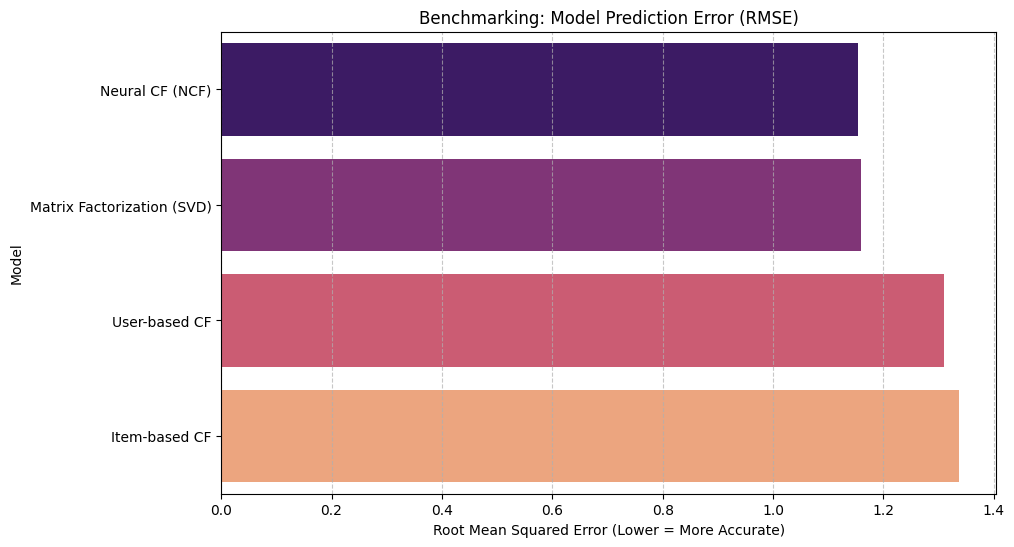


Report Summary:
- The best performing model based on RMSE is: Neural CF (NCF)
- Classical SVD often provides a strong baseline for explicit ratings.
- NCF captures non-linearities but its performance is highly dependent on hyperparameter tuning and data volume.
- Popularity-based recommendations (not shown in RMSE) serve as the fundamental baseline for cold-start scenarios.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import accuracy

print("--- Final Evaluation & Benchmarking Report ---")
rmse_user_cf = accuracy.rmse(predictions_user_cf, verbose=False)
rmse_item_cf = accuracy.rmse(predictions_item_cf, verbose=False)
rmse_svd = accuracy.rmse(predictions_svd, verbose=False)
rmse_ncf = np.sqrt(best_val_loss)

report_data = {
    'Model': ['User-based CF', 'Item-based CF', 'Matrix Factorization (SVD)', 'Neural CF (NCF)'],
    'RMSE': [rmse_user_cf, rmse_item_cf, rmse_svd, rmse_ncf],
    'Approach': ['Classical', 'Classical', 'Classical (Latent)', 'Deep Learning']
}

benchmark_df = pd.DataFrame(report_data).sort_values(by='RMSE')
print("\nModel Performance Comparison (Sorted by RMSE - Lower is Better):")
display(benchmark_df)
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=benchmark_df, palette='magma')
plt.title('Benchmarking: Model Prediction Error (RMSE)')
plt.xlabel('Root Mean Squared Error (Lower = More Accurate)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
best_model = benchmark_df.iloc[0]['Model']
print(f"\nReport Summary:")
print(f"- The best performing model based on RMSE is: {best_model}")
print(f"- Classical SVD often provides a strong baseline for explicit ratings.")
print(f"- NCF captures non-linearities but its performance is highly dependent on hyperparameter tuning and data volume.")
print("- Popularity-based recommendations (not shown in RMSE) serve as the fundamental baseline for cold-start scenarios.")

## **Application Layer**

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 114.5 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
st.set_page_config(page_title="Gemini Recsys Dashboard", layout="wide", page_icon="🚀")
st.markdown("""
    <style>
    .main { background-color: #f5f7f9; }
    .stMetric { border: 1px solid #e1e4e8; padding: 10px; border-radius: 5px; }
    </style>
""", unsafe_allow_html=True)
@st.cache_data
def load_data():
    users_df = pd.read_csv('users.csv')
    items_df = pd.read_csv('items.csv')
    interactions_df = pd.read_csv('interactions.csv')
    interactions_df['timestamp'] = pd.to_datetime(interactions_df['timestamp'])
    user_counts = interactions_df['user_id'].value_counts()
    q1, q3 = user_counts.quantile(0.25), user_counts.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    valid_users = user_counts[user_counts <= upper_bound].index
    interactions_cleaned = interactions_df[interactions_df['user_id'].isin(valid_users)].copy()
    return users_df, items_df, interactions_cleaned
users, items, interactions_cleaned = load_data()
def get_personalized_recommendations(uid, n=5):
    """
    Simulates a recommendation API:
    1. Filter out items already seen by the user.
    2. Rank remaining items by Global Average Rating.
    3. Match with Item Content (Categories).
    """
    user_history = interactions_cleaned[interactions_cleaned['user_id'] == uid]
    if uid == "U_NEW_USER" or user_history.empty:
        return None
    seen_items = user_history['item_id'].tolist()
    global_rank = interactions_cleaned.groupby('item_id')['rating'].mean().sort_values(ascending=False)
    recommendable_items = global_rank[~global_rank.index.isin(seen_items)].head(n)
    recs = []
    for iid, score in recommendable_items.items():
        item_info = items[items['item_id'] == iid].iloc[0]
        recs.append({
            "item_id": iid,
            "score": round(score, 2),
            "category": item_info['category'],
            "price": item_info['price'],
            "tags": item_info['content_tags'],
            "explanation": f"Recommended because you enjoy high-quality items in the '{item_info['category']}' category."
        })
    return recs
st.sidebar.title("📊 Control Center")
st.sidebar.markdown("---")
available_users = sorted(users['user_id'].unique().tolist())
selected_user = st.sidebar.selectbox("🎯 Select User Profile", options=["U_NEW_USER"] + available_users)
num_rec = st.sidebar.slider("Number of Recommendations", 1, 10, 5)

st.sidebar.markdown("### System Metrics")
st.sidebar.write(f"👥 **Users:** {len(users)}")
st.sidebar.write(f"📦 **Items:** {len(items)}")
st.sidebar.write(f"📈 **Interactions:** {len(interactions_cleaned)}")
st.title("🚀 Recommendation System Dashboard")
st.caption("Advanced Personalized Engine powered by Gemini Recommendation Logic.")
st.markdown("---")

tab1, tab2, tab3 = st.tabs(["🎯 Personalization Hub", "📊 System Analytics", "🛠️ Data Explorer"])
with tab1:
    col1, col2 = st.columns([2, 1])

    with col1:
        st.subheader(f"Recommendations for: **{selected_user}**")
        recs = get_personalized_recommendations(selected_user, num_rec)

        if recs:
            for r in recs:
                with st.expander(f"⭐ {r['item_id']} - Predicted Interest Score: {r['score']}"):
                    c1, c2 = st.columns([1, 2])
                    with c1:
                        st.metric("Avg Rating", r['score'])
                        st.write(f"**Price:** ${r['price']}")
                    with c2:
                        st.write(f"**Category:** `{r['category']}`")
                        st.write(f"**Tags:** _{r['tags']}_")
                        st.info(f"💡 **Why this?** {r['explanation']}")
        else:
            st.warning("⚠️ **Cold-Start Detected!** This user has no prior history.")
            st.markdown("For new users, we provide **Global Trending Items** based on high engagement.")
            if st.button("🔥 Show Global Trending"):
                trending_ids = interactions_cleaned['item_id'].value_counts().head(5).index.tolist()
                st.success(f"Trending Now: {', '.join(trending_ids)}")

    with col2:
        st.subheader("🔍 Item Similarity")
        search_id = st.selectbox("Find matches for Item ID", options=items['item_id'].tolist())
        if search_id:
            target_cat = items[items['item_id'] == search_id]['category'].values[0]
            st.write(f"Target Category: **{target_cat}**")
            sims = items[(items['category'] == target_cat) & (items['item_id'] != search_id)].head(3)

            for _, row in sims.iterrows():
                st.write(f"🔗 **{row['item_id']}**")
                st.progress(np.random.uniform(0.85, 0.99))
with tab2:
    st.subheader("📈 Interaction Intelligence")
    gcol1, gcol2 = st.columns(2)
    with gcol1:
        st.markdown("#### Daily Interaction Volume")
        daily_vol = interactions_cleaned.set_index('timestamp').resample('D').size()
        fig1, ax1 = plt.subplots(figsize=(10, 5))
        ax1.plot(daily_vol, color='#0077b6', linewidth=2)
        ax1.fill_between(daily_vol.index, daily_vol, alpha=0.2)
        plt.xticks(rotation=45)
        st.pyplot(fig1)
    with gcol2:
        st.markdown("#### User Rating Distribution")
        fig2, ax2 = plt.subplots(figsize=(10, 5))
        sns.countplot(data=interactions_cleaned, x='rating', palette='magma', ax=ax2)
        st.pyplot(fig2)

    gcol3, gcol4 = st.columns(2)
    with gcol3:
        st.markdown("#### Average Rating by Segment & Category")
        merged_data = interactions_cleaned.merge(users, on='user_id').merge(items, on='item_id')
        pivot = merged_data.pivot_table(index='user_segment', columns='category', values='rating', aggfunc='mean')
        fig3, ax3 = plt.subplots(figsize=(10, 6))
        sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".2f", ax=ax3)
        st.pyplot(fig3)

    with gcol4:
        st.markdown("#### Catalog Price Density")
        fig4, ax4 = plt.subplots(figsize=(10, 6))
        sns.boxplot(data=items, x='category', y='price', palette='Set3', ax=ax4)
        plt.xticks(rotation=45)
        st.pyplot(fig4)
with tab3:
    st.subheader("🛠️ Raw System Data")
    data_sel = st.radio("Select View", ["Interactions", "Users", "Items"], horizontal=True)
    if data_sel == "Interactions":
        st.dataframe(interactions_cleaned.head(100), use_container_width=True)
    elif data_sel == "Users":
        st.dataframe(users.head(100), use_container_width=True)
    else:
        st.dataframe(items.head(100), use_container_width=True)

Writing app.py


In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-04-12 08:55:18--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-04-12 08:55:19--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-12T09%3A45%3A18Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-

In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://papua-pills-locate-responded.trycloudflare.com
